# Finanzas II - I Trimestre 2026

Profesor Fernando Díaz H.

## Instrumentos Norteamericanos 
* Indices Accionarios
* Bonos del Tesoro

### Cargando librerías

In [2]:
install.packages(c("tidyquant", "dplyr", "ggplot2", "lubridate"))

Warning message:
"package 'tidyquant' is in use and will not be installed"
Installing packages into 'C:/Users/fernando.diazh/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependency 'vctrs'


Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/vctrs_0.7.3.zip': Timeout of 60 seconds was reached"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/dplyr_1.2.1.zip': Timeout of 60 seconds was reached"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/ggplot2_4.0.2.zip': Timeout of 60 seconds was reached"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.5/lubridate_1.9.5.zip': Timeout of 60 seconds was reached"


Error in download.file(urls, destfiles, "libcurl", mode = "wb", ...) : 
  cannot download any files


Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
"download of package 'vctrs' failed"
Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
"download of package 'dplyr' failed"
Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
"download of package 'ggplot2' failed"
Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
"download of package 'lubridate' failed"


In [1]:
library(tidyquant)
library(dplyr)
library(ggplot2)
library(lubridate)

Warning message:
"package 'tidyquant' was built under R version 4.5.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"package 'xts' was built under R version 4.5.2"
Warning message:
"package 'zoo' was built under R version 4.5.2"
Warning message:
"package 'quantmod' was built under R version 4.5.2"
Warning message:
"package 'TTR' was built under R version 4.5.2"
Warning message:
"package 'PerformanceAnalytics' was built under R version 4.5.2"
── Attaching core tidyquant packages ─────────────────────── tidyquant 1.0.12 ──
✔ PerformanceAnalytics 2.0.8      ✔ TTR                  0.24.4
✔ quantmod             0.4.28     ✔ xts                  0.14.1
── Conflicts ────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ PerformanceAnalytics::legend() masks graphics::legend()
✖ quantmod::summa

ERROR: Error: package or namespace load failed for 'dplyr' in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 namespace 'vctrs' 0.6.5 is already loaded, but >= 0.7.1 is required


## El Paquete $tidyquant$

$tidyquant$ es un paquete de funciones de análisis financiero, integrado con el ambiente $tidyverse$. Fue creado para facilitar el manejo de datos financieros y series temporales dentro del flujo de trabajo $tidyverse$.

## Indices Disponibles

In [3]:
tq_index_options()

[1] "DOW"       "DOWGLOBAL" "SP400"     "SP500"     "SP600"

## Obteniendo Información del SP500

In [5]:
sp500 <- tq_index('SP500')
sp500

Getting holdings for SP500



symbol,company,identifier,sedol,weight,sector,shares_held,local_currency
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
NVDA,NVIDIA CORP,67066G104,2379504,0.078291963,-,296292871,USD
MSFT,MICROSOFT CORP,594918104,2588173,0.070162422,-,90300364,USD
AAPL,APPLE INC,037833100,2046251,0.058993098,-,181459037,USD
AMZN,AMAZON.COM INC,023135106,2000019,0.040543596,-,114790970,USD
META,META PLATFORMS INC CLASS A,30303M102,B7TL820,0.028675150,-,26376977,USD
AVGO,BROADCOM INC,11135F101,BDZ78H9,0.025082168,-,57122485,USD
GOOGL,ALPHABET INC CL A,02079K305,BYVY8G0,0.020664580,-,70704126,USD
GOOG,ALPHABET INC CL C,02079K107,BYY88Y7,0.016758176,-,57032644,USD
BRK-B,BERKSHIRE HATHAWAY INC CL B,084670702,2073390,0.016282682,-,22276453,USD


# Evolución del SP500 en el Tiempo

Consideremos, por ejemplo, los últimos 30 años.

In [6]:
# Set date range: last 30 years from today
start_date <- today() - years(30)
end_date <- today()

In [7]:
# Download SP500 index data
sp500_data <- tq_get("^GSPC", 
                     from = start_date, 
                     to = end_date)

In [8]:
head(sp500_data )

symbol,date,open,high,low,close,volume,adjusted
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
^GSPC,1995-07-25,556.63,561.75,556.34,561.10,373200000,561.10
^GSPC,1995-07-26,561.10,563.78,560.85,561.61,393470000,561.61
^GSPC,1995-07-27,561.61,565.33,561.61,565.22,356570000,565.22
^GSPC,1995-07-28,565.22,565.40,562.04,562.93,311590000,562.93
^GSPC,1995-07-31,562.93,563.49,560.06,562.06,291950000,562.06
^GSPC,1995-08-01,562.06,562.11,556.67,559.64,332210000,559.64


Grafiquemos el precio de cierre, ajustado por dividendos y splits:

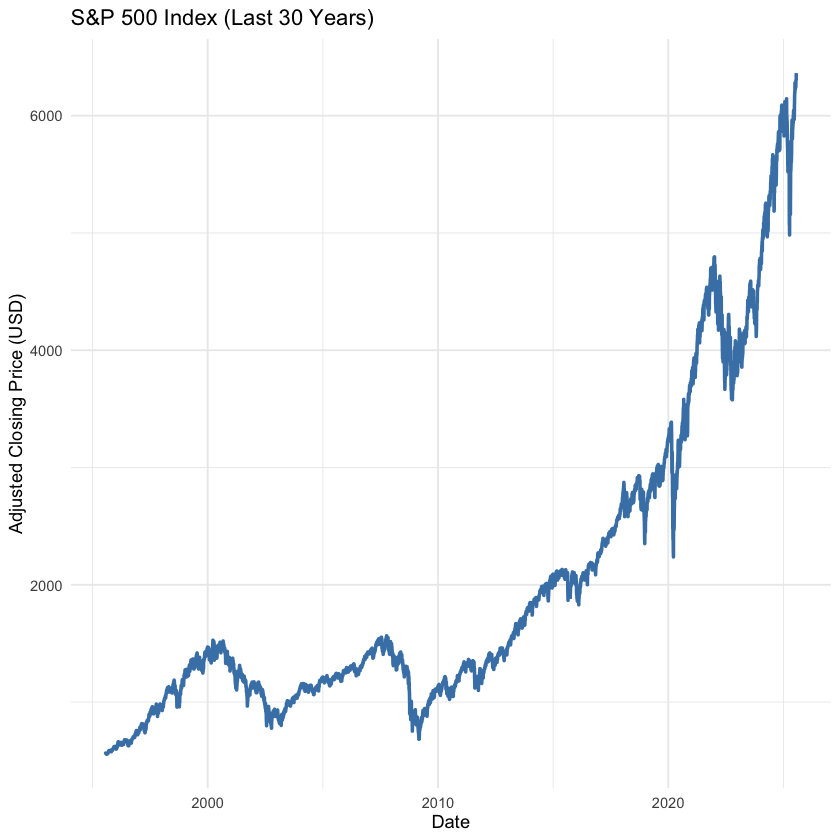

In [10]:
# Plot Adjusted Close Price
sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()


# Diferentes Activos y Clases de Activos

Ahora, para el mismo periodo de tiempo, descargaremos el DOW, el SP600 y las series del Tesoro a 10 años con vencimiento constante. 

Tanto el S&P 500, el S&P 600 como el Dow Jones Industrial Average (DJIA o “el Dow”) pertenecen a la clase de **Renta Variable**, ya que están compuestos por acciones. Los bonos, por su parte, corresponden a la clase de **Renta Fija**.


### 📊 Diferencias entre el S&P 500, S&P 600 y el Dow

| Índice        | ¿Qué representa?                                                                 | Tipo de empresas             | Método de cálculo                      |
|---------------|----------------------------------------------------------------------------------|-------------------------------|----------------------------------------|
| **S&P 500**   | Las 500 mayores empresas de EE.UU. por capitalización bursátil.                  | **Large Cap** (grandes)       | Ponderado por capitalización de mercado |
| **S&P 600**   | 600 empresas pequeñas seleccionadas por su estabilidad y liquidez.               | **Small Cap** (pequeñas)      | Ponderado por capitalización de mercado |
| **Dow Jones** | 30 grandes empresas industriales líderes de EE.UU., muy conocidas.               | **Large Cap** (pero solo 30)  | **Ponderado por precio**, no por capitalización |


## Tendencias Temporales de los Diferentes Activos



* Representaremos todas las series en el mismo gráfico. 
* También normalizaremos el precio de cada instrumento a 100 en la primera fecha para que todos los gráficos empiecen en el mismo punto.
* Consideremos el período que se incia el año 2005.

symbol,date,open,high,low,close,volume,adjusted,label
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
^TNX,2025-07-17,4.477,4.493,4.429,4.463,0,4.463,10Y Treasury
^TNX,2025-07-18,4.424,4.442,4.416,4.432,0,4.432,10Y Treasury
^TNX,2025-07-21,4.368,4.384,4.352,4.372,0,4.372,10Y Treasury
^TNX,2025-07-22,4.372,4.378,4.328,4.336,0,4.336,10Y Treasury
^TNX,2025-07-23,4.358,4.398,4.358,4.388,0,4.388,10Y Treasury
^TNX,2025-07-24,4.408,4.442,4.394,4.408,0,4.408,10Y Treasury


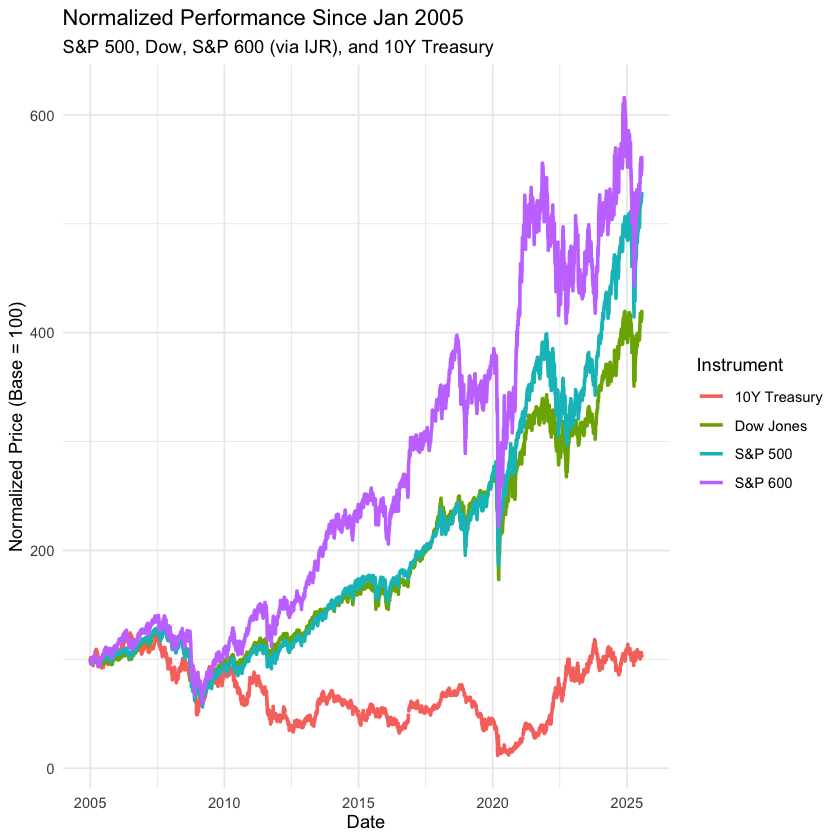

In [11]:

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

# Human-readable labels
labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury")

# Set custom date range
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download data
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Add labels
market_data <- market_data |>
  mutate(label = labels[symbol])

# Normalize to 100 at start date
normalized_data <- market_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(size = 1) +
  labs(
    title = "Normalized Performance Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (via IJR), and 10Y Treasury",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()

tail(market_data)


OK. Nótese que la serie de los bonos del tesoro está espresada en puntos porcentuales. Podemos calcular un precio aproximado:

$$
\text{Price}_t = \frac{100}{(1 + r_t)^{10}}
$$

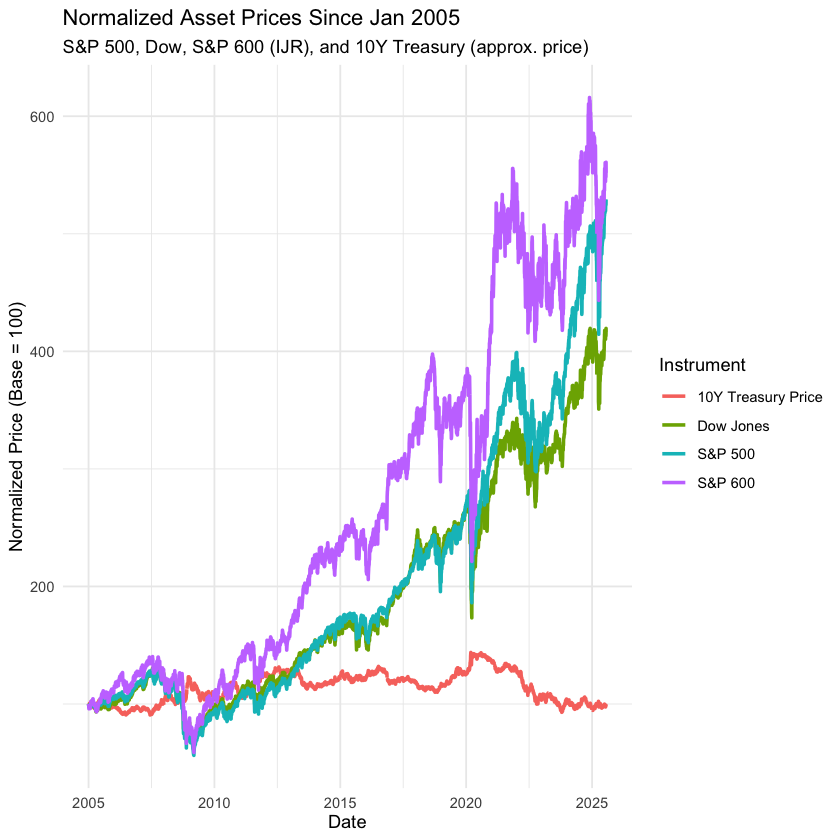

In [12]:
# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],  # assign label before changing symbol
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"  # change symbol last
  )

# Replace TNX data with computed prices
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(size = 1) +
  labs(
    title = "Normalized Asset Prices Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (IJR), and 10Y Treasury (approx. price)",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


# Tendencias

## Tendencias Lineales

Agreguemos una tendencia a cada uno de estos activos:

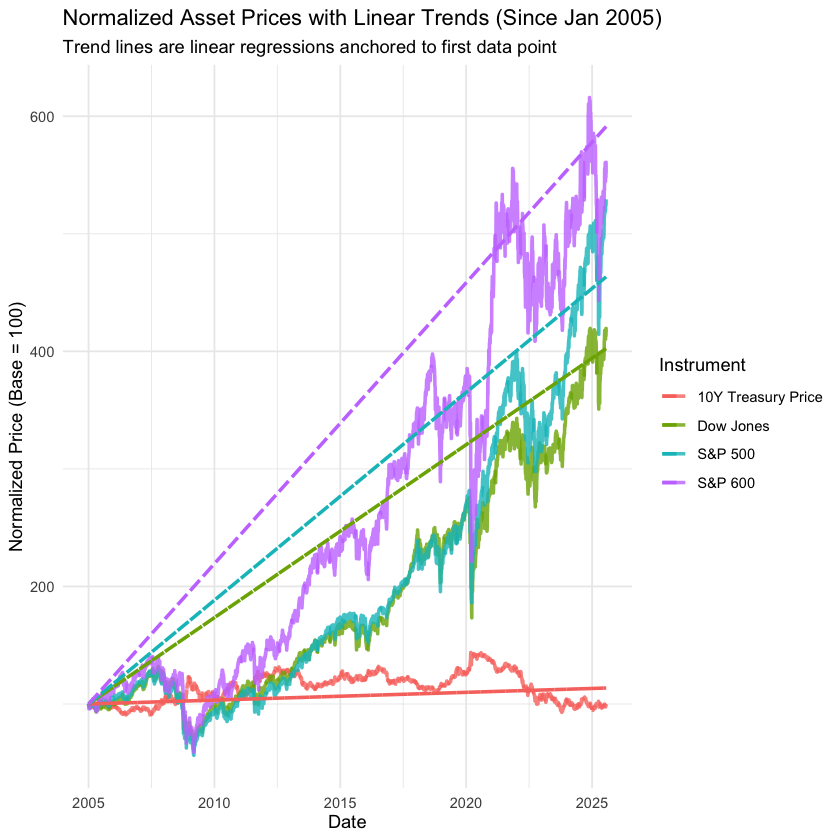

In [13]:
library(tidyquant)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(purrr)

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price, assign label before changing symbol
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"
  )

# Other assets
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine data
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize prices
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Compute linear trends, anchored to first value
trend_data <- normalized_data |>
  group_by(label) |>
  mutate(days_since_start = as.numeric(date - min(date))) |>
  group_modify(~ {
    model <- lm(norm_price ~ days_since_start, data = .x)
    trend <- predict(model, newdata = .x)
    shift <- .x$norm_price[1] - trend[1]
    .x$trend <- trend + shift
    .x
  }) |>
  ungroup()

# Plot
ggplot(trend_data, aes(x = date)) +
  geom_line(aes(y = norm_price, color = label), size = 1, alpha = 0.8) +
  geom_line(aes(y = trend, color = label), linetype = "dashed", size = 1) +
  labs(
    title = "Normalized Asset Prices with Linear Trends (Since Jan 2005)",
    subtitle = "Trend lines are linear regressions anchored to first data point",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


## Retornos Históricos de cada Serie

In [14]:
# 1. Extract ^TNX yield series (not the computed price)
tnx_yield <- market_data |>
  filter(symbol == "^TNX") |>
  arrange(date) |>
  mutate(
    rate = adjusted / 100  # Convert from "TNX units" to decimal yield
  )

# 2. Compute average interest rate (annualized)
avg_yield <- tnx_yield |>
  summarise(
    avg_rate = mean(rate, na.rm = TRUE),
    avg_percent = round(avg_rate * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield")

# 3. Compute average log returns for other series
average_returns <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    annual_log_return = avg_daily_log_return * 252,
    annual_percent = round(annual_log_return * 100, 2)
  ) |>
  ungroup() |>
  select(label, annual_percent)

# 4. Combine returns and yield
final_summary <- bind_rows(
  average_returns,
  avg_yield |> select(label, annual_percent = avg_percent)
)

print(final_summary)


# A tibble: 4 x 2
  label              annual_percent
  <chr>                       <dbl>
1 Dow Jones                    6.95
2 S&P 500                      8.12
3 S&P 600                      8.32
4 10Y Treasury Yield           2.94


## Volatilidad de Cada Serie

Deberíamos observar que a maor retorno, existe mayor volatilidad.

In [15]:
# For equity 
returns_summary <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    sd_daily_log_return = sd(log_return, na.rm = TRUE),
    annual_return = avg_daily_log_return * 252,
    annual_volatility = sd_daily_log_return * sqrt(252),
    return_percent = round(annual_return * 100, 2),
    vol_percent = round(annual_volatility * 100, 2)
  ) |>
  select(label, return_percent, vol_percent)

# For 10Y Treasury yield (raw ^TNX)
tnx_stats <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    yield = adjusted / 100  # Convert to decimal
  ) |>
  summarise(
    return_percent = round(mean(yield, na.rm = TRUE) * 100, 2),
    vol_percent = round(sd(yield, na.rm = TRUE) * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield") |>
  select(label, return_percent, vol_percent)

# Combine everything
final_summary <- bind_rows(returns_summary, tnx_stats)

# Display
print(final_summary)


# A tibble: 4 x 3
  label              return_percent vol_percent
  <chr>                       <dbl>       <dbl>
1 Dow Jones                    6.95       18.2 
2 S&P 500                      8.12       19.3 
3 S&P 600                      8.32       23.7 
4 10Y Treasury Yield           2.94        1.13
